# Colored grid world experiment

A minimal aliased environment: an n×n grid where each cell has a single color ID as its observation.
Border cells are uniquely colored (distinct edges and corners); all interior cells share the same gray color (obs 0).
The agent does a single long random walk and observes only the color of its current cell — no heading, no egocentric patch.

We fit `cscg_he_split` on this sequence and show the recovered transition graph positioned on the true grid layout.

## Imports

In [23]:
import jax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
plt.rcParams.update({'font.size': 14})

from cscg import cscg_se_split as cscg
from cscg import utils


In [24]:
n = 6  # grid size — change this and re-run all cells below

/tmp/ipykernel_406452/1606909208.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_grid = plt.cm.get_cmap('tab10', 9)


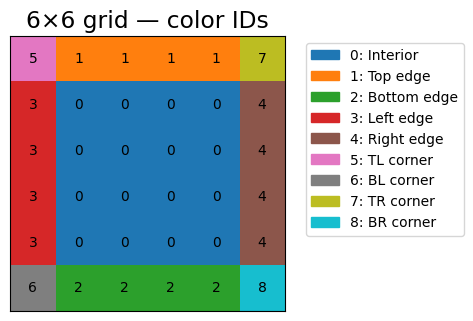

Grid shape: (6, 6)
Unique obs: [0 1 2 3 4 5 6 7 8]


In [25]:
def build_grid(n):
    """Build an n×n color-ID grid."""
    grid = np.zeros((n, n), dtype=int)
    # edges (excluding corners)
    grid[0, 1:-1] = 1   # top
    grid[-1, 1:-1] = 2  # bottom
    grid[1:-1, 0] = 3   # left
    grid[1:-1, -1] = 4  # right
    # corners
    grid[0, 0] = 5    # top-left
    grid[-1, 0] = 6   # bottom-left
    grid[0, -1] = 7   # top-right
    grid[-1, -1] = 8  # bottom-right
    return grid

grid = build_grid(n)

obs_names = [
    'Interior', 'Top edge', 'Bottom edge', 'Left edge', 'Right edge',
    'TL corner', 'BL corner', 'TR corner', 'BR corner',
]

fig, ax = plt.subplots(figsize=(5, 5))
cmap_grid = plt.cm.get_cmap('tab10', 9)
im = ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=8.5)
for r in range(n):
    for c in range(n):
        ax.text(c, r, str(grid[r, c]), ha='center', va='center', fontsize=10, color='k')
ax.set_title(f'{n}×{n} grid — color IDs')
ax.set_xticks([])
ax.set_yticks([])
patches = [mpatches.Patch(color=cmap_grid(i / 8), label=f'{i}: {obs_names[i]}') for i in range(9)]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Grid shape: {grid.shape}')
print(f'Unique obs: {np.unique(grid)}')

## Generate training data

The agent takes one of four cardinal actions (N/E/S/W) uniformly at random.
Moves that would leave the grid are rejected (agent stays in place).
The observation at each step is just the color ID of the current cell.

In [ ]:
def generate_random_walk(grid, length, seed=0):
    """Random walk on grid. Returns (actions, observations, positions).

    Actions: 0=N, 1=E, 2=S, 3=W.
    action[t] is the action taken at step t, causing the transition to step t+1.
    The final action is a dummy (0).
    """
    rng = np.random.default_rng(seed)
    n = grid.shape[0]
    deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]  # N, E, S, W

    r, c = n // 2, n // 2  # start at center
    observations = np.zeros(length, dtype=int)
    actions = np.zeros(length, dtype=int)
    positions = np.zeros((length, 2), dtype=int)

    observations[0] = grid[r, c]
    positions[0] = (r, c)

    for t in range(length - 1):
        a = int(rng.integers(0, 4))
        dr, dc = deltas[a]
        nr, nc = r + dr, c + dc
        if 0 <= nr < n and 0 <= nc < n:
            r, c = nr, nc
        actions[t] = a
        observations[t + 1] = grid[r, c]
        positions[t + 1] = (r, c)

    return actions, observations, positions

length = 120000
a, x, pos_walk = generate_random_walk(grid, length, seed=42)

print(f'Sequence length: {length:,}')
print(f'Unique observations: {np.unique(x)}')

# Check coverage
visited = set(map(tuple, pos_walk))
print(f'Grid cells visited: {len(visited)} / {n*n}')

Sequence length: 80,000
Unique observations: [0 1 2 3 4 5 6 7 8]
Grid cells visited: 36 / 36


## CSCG setup

Clone allocation: one clone per grid cell sharing that observation.
- Interior cells (obs 0): (n−2)² clones
- Each edge obs (1–4): (n−2) clones
- Each corner obs (5–8): 1 clone

In [27]:
n_obs = int(grid.max()) + 1
n_clones = 3*np.array([(grid == i).sum() for i in range(n_obs)], dtype=int)
print('Observation counts / n_clones:')
for i, (name, nc) in enumerate(zip(obs_names, n_clones)):
    print(f'  obs {i} ({name}): {nc} clone(s)')
print(f'Total states: {n_clones.sum()} (expected {n*n})')

Observation counts / n_clones:
  obs 0 (Interior): 48 clone(s)
  obs 1 (Top edge): 12 clone(s)
  obs 2 (Bottom edge): 12 clone(s)
  obs 3 (Left edge): 12 clone(s)
  obs 4 (Right edge): 12 clone(s)
  obs 5 (TL corner): 3 clone(s)
  obs 6 (BL corner): 3 clone(s)
  obs 7 (TR corner): 3 clone(s)
  obs 8 (BR corner): 3 clone(s)
Total states: 108 (expected 36)


In [28]:
# Trim sequence length to be divisible by n_devices * num_splits (required by pmap + split)
num_splits = 10
n_devices = jax.device_count()
T = (length // (n_devices * num_splits)) * (n_devices * num_splits)
x_train, a_train = x[:T], a[:T]
pos_train = pos_walk[:T]
print(f'Training sequence length: {T:,} (devices={n_devices}, splits={num_splits})')

pseudocount = 5e-4
model = cscg.CSCG(
    n_clones=n_clones,
    pseudocount=pseudocount,
    n_actions=4,
    seed=0,
    batched=True,
    use_bfloat16=False,
    num_splits=num_splits,
)
print(f'Model: {model.implementation}, {model.num_states} states, {model.num_emissions} emissions')

Training sequence length: 80,000 (devices=8, splits=10)
Model: se_split_10, 108 states, 9 emissions


## Training

  0%|          | 0/200 [00:00<?, ?it/s]

 42%|████▏     | 83/200 [00:12<00:17,  6.87it/s, train_bps=0.005588399] 


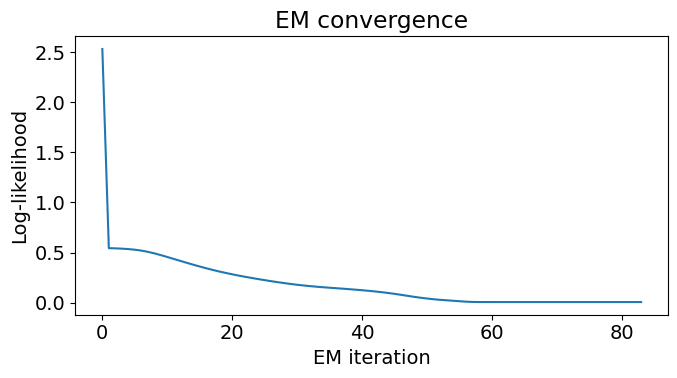

In [29]:
# EM learning
convergence_em = model.learn_em_transition(
    observations=x_train, actions=a_train, n_iter=200, term_early=True,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(convergence_em)
ax.set_xlabel('EM iteration')
ax.set_ylabel('Log-likelihood')
ax.set_title('EM convergence')
plt.tight_layout()
plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:00<00:07,  1.13it/s, train_bps=1.8821527] 


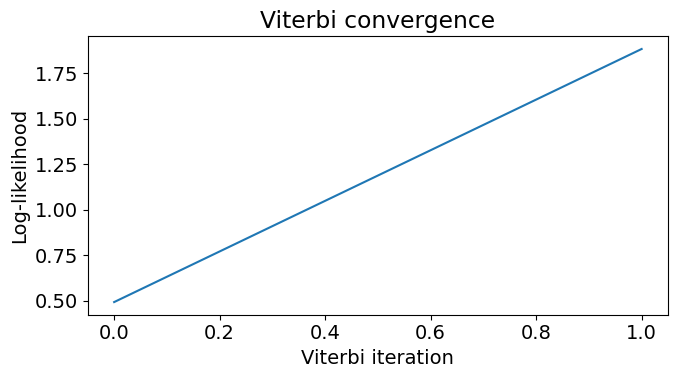

In [30]:
# Viterbi learning
convergence_vit = model.learn_viterbi_transition(
    observations=x_train, actions=a_train, n_iter=10
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(convergence_vit)
ax.set_xlabel('Viterbi iteration')
ax.set_ylabel('Log-likelihood')
ax.set_title('Viterbi convergence')
plt.tight_layout()
plt.show()

## Decode and visualize

In [31]:
states = np.array(model.decode(observations=x_train, actions=a_train)[1])
print(f'Grid cells: {n*n}, unique decoded states: {len(np.unique(states))}')

Grid cells: 36, unique decoded states: 75


In [32]:
# Map each decoded state to its most frequently visited grid position.
state_pos_counts = {}
for t, s in enumerate(states):
    rc = (int(pos_train[t, 0]), int(pos_train[t, 1]))
    if s not in state_pos_counts:
        state_pos_counts[s] = {}
    state_pos_counts[s][rc] = state_pos_counts[s].get(rc, 0) + 1

state_to_pos = {s: max(cnt, key=cnt.get) for s, cnt in state_pos_counts.items()}

# Build pos dict for plot_graph.
# Graph node i corresponds to np.unique(states)[i].
# Position: x = col, y = -row so that row 0 appears at the top.
unique_states = np.unique(states)
pos_graph = {
    i: (state_to_pos[s][1], -state_to_pos[s][0])
    for i, s in enumerate(unique_states)
}

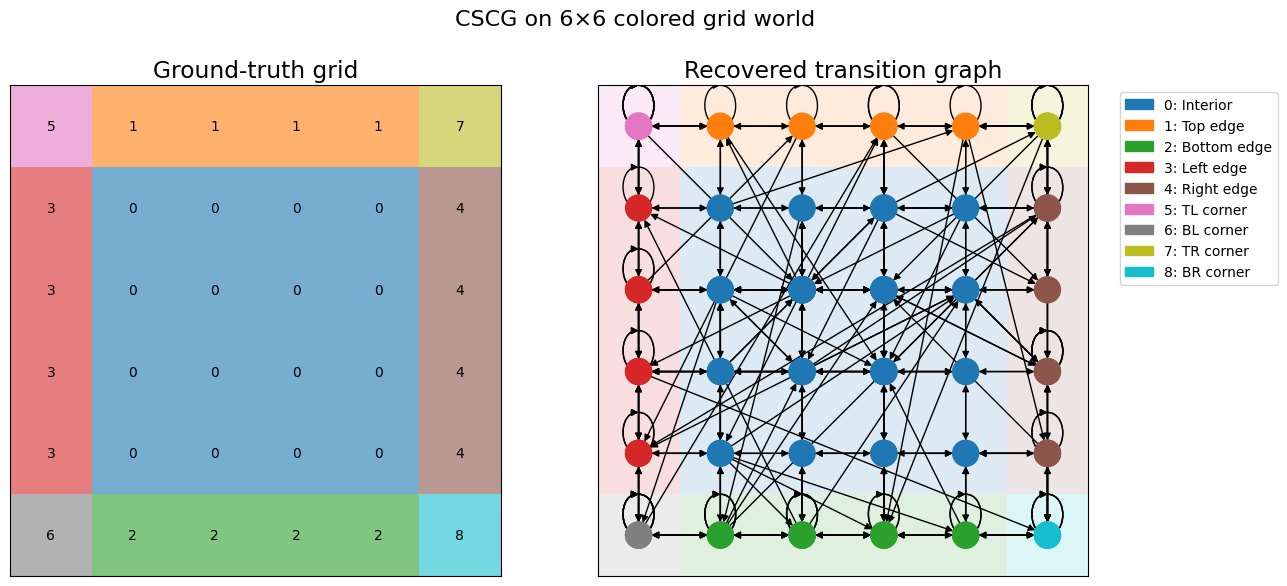

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ground-truth grid
ax = axes[0]
im = ax.imshow(grid, cmap=cmap_grid, vmin=-0.5, vmax=8.5, alpha=0.6)
for r in range(n):
    for c in range(n):
        ax.text(c, r, str(grid[r, c]), ha='center', va='center', fontsize=10)
ax.set_title('Ground-truth grid')
ax.set_xticks([])
ax.set_yticks([])

# Right: recovered transition graph, nodes placed at true grid positions
ax = axes[1]
# faint grid background
ax.imshow(
    grid, cmap=cmap_grid, vmin=-0.5, vmax=8.5, alpha=0.15,
    extent=[-0.5, n - 0.5, -(n - 0.5), 0.5],
)
utils.plot_graph(
    model.counts_matrix,
    states,
    n_clones,
    x_train.max(),
    ax=ax,
    pos=pos_graph,
    node_size=350,
    threshold=0.0,
    cmap='tab10',
)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(-(n - 0.5), 0.5)
ax.set_title('Recovered transition graph')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

patches = [mpatches.Patch(color=cmap_grid(i / 8), label=f'{i}: {obs_names[i]}') for i in range(9)]
axes[1].legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.suptitle(f'CSCG on {n}×{n} colored grid world', fontsize=16)
plt.tight_layout()
plt.show()